# The private capital map (Form D)

Companies raising money privately under Regulation D file a Form D:
319K+ of them from 186K distinct issuers, and almost nobody parses
these. The list endpoint carries the industry group and offering
amounts directly, so a market map is a few loops away.

Market-wide date scans on this family allow 31 day windows, so we walk
six months in monthly slices.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import datetime as dt

import pandas as pd

from py3spread import Client

client = Client()

MONTHS = 6
end = dt.date.today().replace(day=1)

frames = []
for _ in range(MONTHS):
    start = (end - dt.timedelta(days=1)).replace(day=1)
    rows = [
        {"month": str(start)[:7],
         "industry": r["industry_group_type"],
         "amount": r["total_offering_amount"],
         "filer": r["filer_name"]}
        for r in client.private_offerings.iter(
            accepted_start=str(start), accepted_end=str(end - dt.timedelta(days=1)))
        if not r["is_amendment"]
    ]
    frames.append(pd.DataFrame(rows))
    print(f"{start:%Y-%m}: {len(rows)} new offerings")
    end = start

df = pd.concat(frames, ignore_index=True)
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
print(f"total: {len(df)} offerings")

2026-06: 454 new offerings


2026-05: 921 new offerings


2026-04: 3918 new offerings


2026-03: 3642 new offerings


2026-02: 3040 new offerings


2026-01: 3440 new offerings
total: 15415 offerings


## Offerings by industry and month

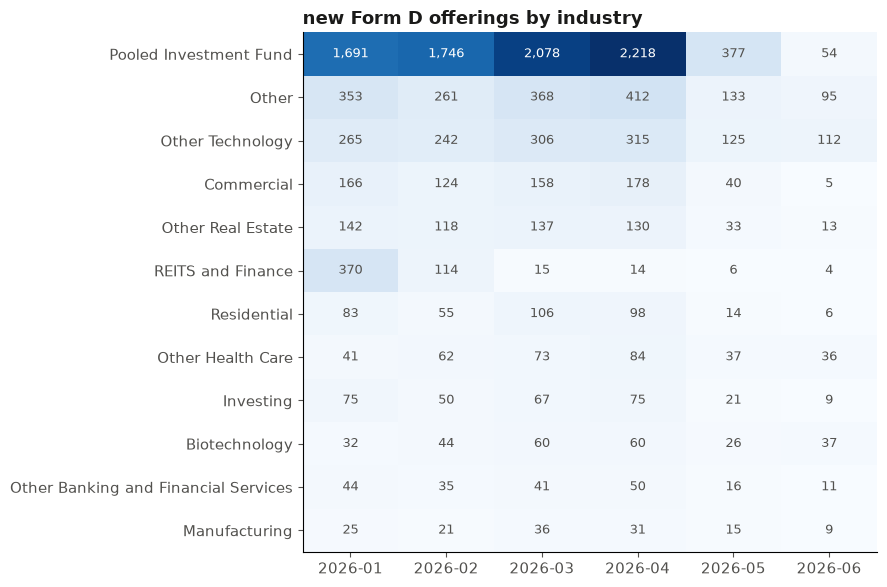

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


import numpy as np

top = df["industry"].value_counts().head(12).index
pivot = (df[df["industry"].isin(top)]
         .pivot_table(index="industry", columns="month", aggfunc="size", fill_value=0)
         .loc[top])

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.grid(visible=False)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=9,
                color="white" if v > pivot.values.max() * 0.55 else INK)
ax.set_title("new Form D offerings by industry", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

Same beta caveat as elsewhere: the fading recent columns reflect what
has been ingested so far, not a private-capital drought. Check
`client.coverage.intake()` before reading the time axis as market
signal; sector mix within a column is unaffected.


## Largest raises in the window

In [3]:
biggest = (df.dropna(subset=["amount"])
           .sort_values("amount", ascending=False)
           .head(10)[["month", "filer", "industry", "amount"]])
biggest.style.format({"amount": "${:,.0f}"}).hide(axis="index")

month,filer,industry,amount
2026-02,Shabazz Abdul-Rahman Mateen,Other Banking and Financial Services,"$100,000,000,000"
2026-03,"Melodious Horse Holdings, LLC",Other,"$30,000,000,000"
2026-01,X.AI Holdings Corp.,Other Technology,"$19,999,999,972"
2026-04,Madison Air Solutions Corp,Other,"$10,870,596,090"
2026-04,European Diversified Infrastructure Fund IV SCSp,Pooled Investment Fund,"$6,444,808,999"
2026-03,"Founders Fund Growth IV, LP",Pooled Investment Fund,"$6,024,585,000"
2026-03,"Founders Fund Growth IV Principals Fund, LP",Pooled Investment Fund,"$6,024,585,000"
2026-02,"Battery Ventures XV, L.P.",Pooled Investment Fund,"$3,250,000,000"
2026-02,Kline Hill Partners Offshore Feeder Fund VI LP,Pooled Investment Fund,"$2,700,000,000"
2026-02,Kline Hill Partners Feeder Fund VI LP,Pooled Investment Fund,"$2,700,000,000"


Amounts are as filed; funds often report indefinite offering sizes,
which arrive as nulls here and are excluded from the ranking. Swap
`aggfunc` to sum amounts for a dollar-weighted map, or filter
`investment_fund_type` to separate operating companies from pooled
funds.